In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

###데이터 준비

In [18]:
# x를 넘파이 배열로 정의
x_np = np.arange(-2, 2.1, 0.25)
print(x_np)

[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.  ]


In [19]:
# 1. 경사 계산용 변수 정의
x = torch.tensor(x_np, requires_grad=True, dtype=torch.float32)
# 경사용 변수 선언 및 dtype 옵션 명시적 지정
print(x)

tensor([-2.0000, -1.7500, -1.5000, -1.2500, -1.0000, -0.7500, -0.5000, -0.2500,
         0.0000,  0.2500,  0.5000,  0.7500,  1.0000,  1.2500,  1.5000,  1.7500,
         2.0000], requires_grad=True)


###2차 함수 계산

In [20]:
# 2차 함수 계산
# 계산 그래프는 내부에 자동 생성

y = 2 * x**2 + 2

In [21]:
# y의 계산 결과 확인
print(y)

tensor([10.0000,  8.1250,  6.5000,  5.1250,  4.0000,  3.1250,  2.5000,  2.1250,
         2.0000,  2.1250,  2.5000,  3.1250,  4.0000,  5.1250,  6.5000,  8.1250,
        10.0000], grad_fn=<AddBackward0>)


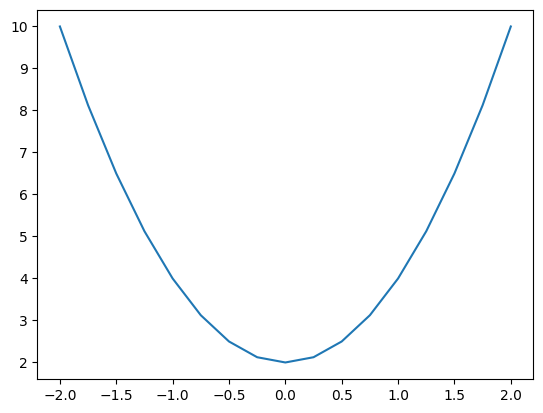

In [22]:
# 그래프 출력
plt.plot(x.data, y.data)
plt.show()

In [23]:
# 경사 계산을 위해 최종 값은 스칼라일 필요가 있다.
# 더미로 sum 함수를 붙임.
z = y.sum()
# sum 쓰는 이유
# 벡터인 y값을 스칼라로 만들기
# 모든 원소를 동일하게 반영하면서 미분이 단순해짐

In [26]:
!pip install torchviz | tail -n 1

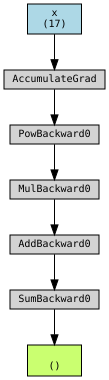

In [27]:
# 3. 계산 그래프 시각화
from torchviz import make_dot

# 시각화 함수 호출
g = make_dot(z, params={'x':x})
display(g)

In [28]:
# 4. 경사 계산
z.backward()

In [30]:
# 5. 경사값 가져오기
print(x.grad)

tensor([-8., -7., -6., -5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,
         6.,  7.,  8.])


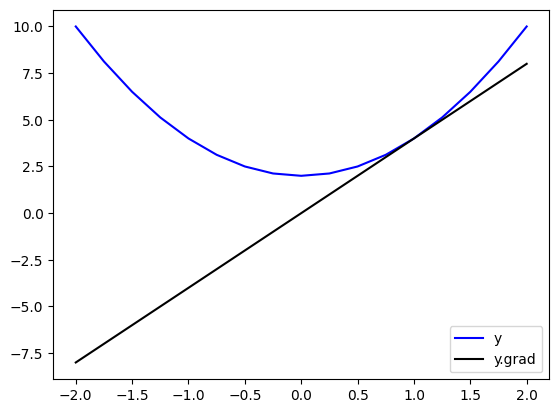

In [31]:
# 원래 함수와 경사 그래프
plt.plot(x.data, y.data, c='b', label='y')
plt.plot(x.data, x.grad.data, c='k', label='y.grad')
plt.legend()
plt.show()

In [34]:
# 6. 경사값 초기화
x.grad.zero_()
print(x.grad)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


### 시그모이드 함수 구현

In [36]:
# 시그모이드 함수 정의
def sigmoid(x):
    return (1 / (1+ torch.exp(-x)))

In [38]:
# 2. y값 계산
y = sigmoid(x)

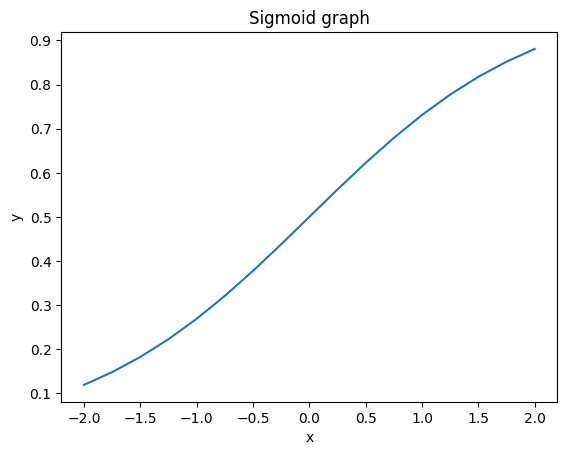

In [39]:
# 그래프(산포도) 출력
plt.plot(x.data, y.data)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Sigmoid graph")
plt.show()

In [41]:
# 경사 계산을 위해 최종 값은 스칼라 형태
# 더미로 sum 함수를 붙여 스칼라 계산
z = y.sum()

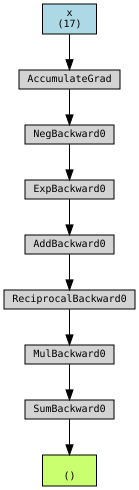

In [42]:
# 3. 계산 그래프 시각화
params = {'x':x}
g = make_dot(z, params=params)
display(g)

In [43]:
# 4. 경사 계산
z.backward()
# 5. 경사값 확인
print(x.grad)

tensor([0.1050, 0.1261, 0.1491, 0.1731, 0.1966, 0.2179, 0.2350, 0.2461, 0.2500,
        0.2461, 0.2350, 0.2179, 0.1966, 0.1731, 0.1491, 0.1261, 0.1050])


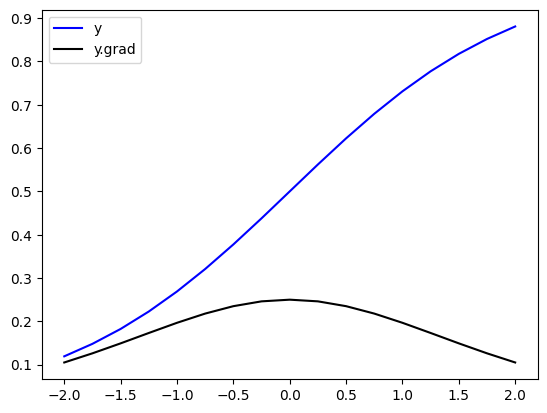

In [44]:
# 원래 함수와 경사 그래프 확인
plt.plot(x.data, y.data, c='b', label='y')
plt.plot(x.data, x.grad.data, c='k', label='y.grad')
plt.legend()
plt.show()

In [45]:
# eos